# 🎶 Building a Reusable Music Metadata Pipeline using the MusicBrainz API 🎧ྀི

A complete data engineering workflow for collecting release, track, artist, and ISRC metadata from major Indian music labels using the MusicBrainz API. Includes caching, retry logic, exploratory data analysis, and exports to CSV and Parquet.

This notebook builds a structured track-level dataset using the MusicBrainz API. The dataset focuses on selected Indian music labels and collects release metadata, track names, artist credits, ISRC codes, MusicBrainz release IDs, and recording URLs.

The workflow includes API-based data collection, dataset creation, export to CSV and Parquet, exploratory data analysis, visualization, and summary reporting.

## 1. Installing Required Packages

This section installs the external Python packages required for the notebook.

The notebook uses:

- `requests-cache` for caching MusicBrainz API responses
- `pyarrow` for saving the dataset in Parquet format
- `tqdm` for progress bars
- `tabulate` for creating Markdown tables in the summary report

These packages help make the data collection process more reliable, efficient, and suitable for Kaggle dataset publishing.

In [1]:
# -----------------------------
# 1. Install required packages
# -----------------------------

import sys
import subprocess

packages = [
    "requests-cache",
    "pyarrow",
    "tqdm",
    "tabulate"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Packages installed successfully.")

Packages installed successfully.


## 2. Importing Libraries

This section imports the libraries required for data collection, processing, visualization, and reporting.

The notebook uses standard Python libraries for logging, time handling, file paths, and type hints. It also uses `requests` for API calls, `pandas` for dataset creation, `matplotlib` for visualizations, and IPython display tools for showing tables and Markdown reports inside the notebook.

In [2]:
# -----------------------------
# 2. Import libraries
# -----------------------------

import time
import logging
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple

import requests
import requests_cache
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display, Markdown

## 3. Configuration

This section defines the main settings for the notebook.

It includes the Kaggle output directory, MusicBrainz API details, request settings, selected music labels, date range, output file names, and label aliases.

The `LABELS` list controls which music labels are included in the dataset. The `START_DATE` and `END_DATE` values control the release date range. The `MAX_RELEASES_PER_LABEL` setting can be used to limit the number of releases collected per label, which is useful for testing or reducing execution time.

The label aliases improve matching because some labels are stored in MusicBrainz under official or alternate names.

In [12]:
# -----------------------------
# 3. Configuration
# -----------------------------

# Kaggle output directory
OUTPUT_DIR = Path("/kaggle/working")

# Use a project contact email.
# Do not publish your personal email if you do not want it public.
CONTACT = "contact@example.com"

BASE_URL = "https://musicbrainz.org/ws/2"
USER_AGENT = f"IndianMusicISRCFetcher/2.0 ({CONTACT})"

REQUEST_DELAY_SECONDS = 1.05
MAX_RETRIES = 7
REQUEST_TIMEOUT = 40

# Change labels and date range here
LABELS = [
    "Zee Music Company",
    "Sony Music India",
    "Saregama",
    "Tips Music",
    "Times Music",
    "Junglee Music",
    "YRF Music",
    "Ishtar Music",
    "Eros Now Music",
]

START_DATE = "2025-01-01"
END_DATE = "2026-01-31"

# Use None to collect all releases.
# Use a number like 10, 20, or 50 to reduce dataset size.
MAX_RELEASES_PER_LABEL = None

OUTPUT_BASENAME = f"musicbrainz_isrc_{START_DATE}_to_{END_DATE}"

OUTPUT_CSV = OUTPUT_DIR / f"{OUTPUT_BASENAME}.csv"
OUTPUT_PARQUET = OUTPUT_DIR / f"{OUTPUT_BASENAME}.parquet"
SUMMARY_REPORT = OUTPUT_DIR / f"{OUTPUT_BASENAME}_summary_report.md"

TRACKS_BY_LABEL_PLOT = OUTPUT_DIR / "tracks_by_label.png"
TRACKS_BY_MONTH_PLOT = OUTPUT_DIR / "tracks_by_month.png"
ISRC_COVERAGE_PLOT = OUTPUT_DIR / "isrc_coverage_by_label.png"
TOP_ARTISTS_PLOT = OUTPUT_DIR / "top_artists.png"
RELEASE_SIZE_PLOT = OUTPUT_DIR / "release_size_distribution.png"

LABEL_ALIASES = {
    "Sony Music India": [
        "Sony Music Entertainment India",
        "Sony Music Entertainment",
        "Sony Music",
    ],
    "Tips Music": [
        "Tips Industries",
        "Tips",
    ],
    "Zee Music Company": [
        "Zee Music",
        "Zee Music Co.",
    ],
    "YRF Music": [
        "Yash Raj Films",
        "Yash Raj Music",
    ],
    "Eros Now Music": [
        "Eros Music",
        "Eros International",
    ],
}

## 4. Logging Setup

This section configures logging for the notebook.

Logging is used instead of simple print statements so that the data collection process is easier to monitor. It helps track which label is being processed, how many releases are found, and whether any API or network errors occur during execution.

In [13]:
# -----------------------------
# 4. Logging setup
# -----------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

logger = logging.getLogger(__name__)

## 5. Helper Functions

This section defines reusable helper functions used during data processing.

The `parse_date()` function standardizes MusicBrainz date values, which may appear as full dates, year-month values, or year-only values.

The `extract_artist_credit()` function extracts artist names from MusicBrainz’s nested artist-credit structure and converts them into a readable comma-separated format.

In [14]:
# -----------------------------
# 5. Helper functions
# -----------------------------

def parse_date(date_value: Optional[str]):
    """
    Parse a MusicBrainz date string.

    MusicBrainz dates may appear as:
    YYYY-MM-DD, YYYY-MM, or YYYY.
    """
    if not date_value:
        return None

    for fmt in ("%Y-%m-%d", "%Y-%m", "%Y"):
        try:
            return datetime.strptime(date_value, fmt).date()
        except ValueError:
            continue

    return None


def extract_artist_credit(recording: Dict[str, Any], track: Dict[str, Any]) -> str:
    """
    Extract artist names from MusicBrainz recording or track artist-credit field.
    """
    artist_credit = recording.get("artist-credit") or track.get("artist-credit") or []

    artists = []

    for item in artist_credit:
        if isinstance(item, dict) and "name" in item:
            artists.append(item["name"])

    return ", ".join(artists)


## 6. MusicBrainz API Client

This section defines the API client used to communicate with MusicBrainz.

The client includes a valid User-Agent, request delay, retry handling, timeout handling, and cached responses. These features make the collection process more responsible and stable.

Caching is useful because repeated notebook runs do not need to call the same API endpoints again unnecessarily.

In [15]:
# -----------------------------
# 6. MusicBrainz API client
# -----------------------------

class MusicBrainzClient:
    """
    MusicBrainz API client with:
    - valid User-Agent
    - rate limiting
    - retry handling
    - cached responses
    """

    def __init__(self) -> None:
        self.session = requests_cache.CachedSession(
            cache_name=str(OUTPUT_DIR / "musicbrainz_cache"),
            backend="sqlite",
            expire_after=60 * 60 * 24 * 7,
        )

        self.session.headers.update({"User-Agent": USER_AGENT})

    def get(
        self,
        endpoint: str,
        params: Optional[Dict[str, Any]] = None
    ) -> Dict[str, Any]:
        """
        Make a GET request to the MusicBrainz API.
        """
        url = f"{BASE_URL}/{endpoint}"

        for attempt in range(MAX_RETRIES):
            try:
                time.sleep(REQUEST_DELAY_SECONDS)

                response = self.session.get(
                    url,
                    params=params,
                    timeout=REQUEST_TIMEOUT,
                )

                if response.status_code == 200:
                    return response.json()

                if response.status_code in (429, 502, 503, 504):
                    wait_time = min(30, 2 ** attempt)
                    logger.warning(
                        "HTTP %s. Retrying in %s seconds.",
                        response.status_code,
                        wait_time,
                    )
                    time.sleep(wait_time)
                    continue

                raise RuntimeError(
                    f"MusicBrainz error {response.status_code}: {response.text[:300]}"
                )

            except (
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout,
                requests.exceptions.ChunkedEncodingError,
            ) as error:
                wait_time = min(30, 2 ** attempt)
                logger.warning(
                    "Network error: %s. Retrying in %s seconds.",
                    error,
                    wait_time,
                )
                time.sleep(wait_time)

        raise RuntimeError(f"Failed after {MAX_RETRIES} retries: {url}")

## 7. Data Collection Functions

This section contains the main functions used to collect MusicBrainz data.

The process has three main steps:

1. Resolve each input label name to its official MusicBrainz label record.
2. Search for releases associated with that label within the selected date range.
3. Fetch track-level metadata and ISRC codes for each release.

The final collection function combines all records into a structured pandas DataFrame. Each row represents one track.

In [16]:
# -----------------------------
# 7. Data collection functions
# -----------------------------

def find_label_id(client: MusicBrainzClient, label_name: str) -> Tuple[str, str]:
    """
    Resolve a label name to a MusicBrainz label ID and official display name.
    """
    candidates = [label_name]
    candidates.extend(LABEL_ALIASES.get(label_name, []))

    for candidate in candidates:
        exact_data = client.get(
            "label",
            params={
                "query": f'label:"{candidate}"',
                "fmt": "json",
                "limit": 5,
            },
        )

        exact_labels = exact_data.get("labels", [])
        if exact_labels:
            best = exact_labels[0]
            return best["id"], best.get("name", candidate)

        loose_data = client.get(
            "label",
            params={
                "query": candidate,
                "fmt": "json",
                "limit": 5,
            },
        )

        loose_labels = loose_data.get("labels", [])
        if loose_labels:
            best = loose_labels[0]
            return best["id"], best.get("name", candidate)

    raise ValueError(f"No MusicBrainz label found for: {label_name}")


def search_releases_for_label(
    client: MusicBrainzClient,
    label_display_name: str,
    start_date: str,
    end_date: str,
) -> List[Dict[str, Any]]:
    """
    Search MusicBrainz releases for a selected label and date range.
    """
    all_releases = []
    limit = 100
    offset = 0

    query = f'label:"{label_display_name}" AND date:[{start_date} TO {end_date}]'

    while True:
        data = client.get(
            "release",
            params={
                "query": query,
                "fmt": "json",
                "limit": limit,
                "offset": offset,
            },
        )

        releases = data.get("releases", [])
        total_count = data.get("release-count", 0)

        all_releases.extend(releases)

        logger.info(
            "Fetched %s/%s releases for %s",
            len(all_releases),
            total_count,
            label_display_name,
        )

        offset += limit

        if len(all_releases) >= total_count or not releases:
            break

    return all_releases


def fetch_tracks_with_isrc(
    client: MusicBrainzClient,
    release_id: str,
) -> List[Dict[str, Any]]:
    """
    Fetch track-level metadata and ISRCs for a MusicBrainz release.
    """
    data = client.get(
        f"release/{release_id}",
        params={
            "fmt": "json",
            "inc": "recordings+isrcs+artist-credits",
        },
    )

    release_title = data.get("title", "")
    release_date = data.get("date", "")
    release_status = data.get("status", "")
    release_country = data.get("country", "")
    release_barcode = data.get("barcode", "")
    release_id = data.get("id", "")

    rows = []

    for media in data.get("media", []) or []:
        medium_format = media.get("format", "")
        medium_position = media.get("position", "")

        for track in media.get("tracks", []) or []:
            track_number = track.get("position")
            track_title = track.get("title", "")
            track_length_ms = track.get("length")

            recording = track.get("recording", {}) or {}
            recording_id = recording.get("id", "")

            isrcs = recording.get("isrcs", []) or []
            isrc_string = "; ".join(isrcs) if isrcs else ""

            artist = extract_artist_credit(recording, track)

            rows.append(
                {
                    "release_date": release_date,
                    "release_title": release_title,
                    "release_status": release_status,
                    "release_country": release_country,
                    "release_barcode": release_barcode,
                    "medium_format": medium_format,
                    "medium_position": medium_position,
                    "track_number": track_number,
                    "track_title": track_title,
                    "artist": artist,
                    "track_length_ms": track_length_ms,
                    "isrc": isrc_string,
                    "has_isrc": bool(isrcs),
                    "release_id": release_id,
                    "recording_id": recording_id,
                    "musicbrainz_release_url": f"https://musicbrainz.org/release/{release_id}",
                    "musicbrainz_recording_url": (
                        f"https://musicbrainz.org/recording/{recording_id}"
                        if recording_id
                        else ""
                    ),
                }
            )

    return rows


def collect_musicbrainz_dataset() -> pd.DataFrame:
    """
    Collect track-level MusicBrainz ISRC data for selected labels.
    """
    client = MusicBrainzClient()

    all_rows = []
    seen = set()

    for label in tqdm(LABELS, desc="Processing labels"):
        logger.info("Processing label: %s", label)

        try:
            label_id, label_display_name = find_label_id(client, label)
            logger.info("Resolved label: %s | ID: %s", label_display_name, label_id)

        except Exception as error:
            logger.exception("Label search failed for %s: %s", label, error)
            continue

        try:
            releases = search_releases_for_label(
                client=client,
                label_display_name=label_display_name,
                start_date=START_DATE,
                end_date=END_DATE,
            )

        except Exception as error:
            logger.exception("Release search failed for %s: %s", label, error)
            continue

        if MAX_RELEASES_PER_LABEL is not None:
            releases = releases[:MAX_RELEASES_PER_LABEL]

        logger.info(
            "Using %s releases for label %s",
            len(releases),
            label_display_name,
        )

        for release in tqdm(
            releases,
            desc=f"Fetching tracks: {label_display_name}",
            leave=False,
        ):
            release_id = release.get("id")

            if not release_id:
                continue

            try:
                track_rows = fetch_tracks_with_isrc(client, release_id)

            except Exception as error:
                logger.warning("Failed release %s: %s", release_id, error)
                continue

            for row in track_rows:
                dedupe_key = (
                    row.get("isrc") or row.get("recording_id"),
                    row.get("track_title"),
                    row.get("artist"),
                )

                if dedupe_key in seen:
                    continue

                seen.add(dedupe_key)

                row["label"] = label_display_name
                row["label_query"] = label
                row["label_id"] = label_id

                all_rows.append(row)

    df = pd.DataFrame(all_rows)

    if not df.empty:
        df["release_date_parsed"] = df["release_date"].apply(parse_date)

        df["release_year"] = pd.to_datetime(
            df["release_date_parsed"],
            errors="coerce",
        ).dt.year

        df["release_month"] = pd.to_datetime(
            df["release_date_parsed"],
            errors="coerce",
        ).dt.to_period("M").astype(str)

        df = df.sort_values(
            by=[
                "label",
                "release_date_parsed",
                "release_title",
                "track_number",
            ],
            na_position="last",
        )

    return df

## 8. Exploratory Data Analysis Functions

This section creates summary tables for understanding the collected dataset.

The EDA includes:

- Number of tracks collected by label
- Number of tracks released by month
- ISRC coverage by label
- Top artists by number of tracks
- Distribution of release sizes

These summaries help evaluate the coverage, completeness, and structure of the dataset.

In [17]:
# -----------------------------
# 8. EDA functions
# -----------------------------

def create_eda_tables(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """
    Create summary tables for Kaggle notebook display.
    """
    eda_tables = {}

    eda_tables["tracks_by_label"] = (
        df.groupby("label")
        .size()
        .reset_index(name="track_count")
        .sort_values("track_count", ascending=False)
    )

    eda_tables["tracks_by_month"] = (
        df.groupby("release_month")
        .size()
        .reset_index(name="track_count")
        .sort_values("release_month")
    )

    eda_tables["isrc_coverage_by_label"] = (
        df.groupby("label")["has_isrc"]
        .mean()
        .mul(100)
        .reset_index(name="isrc_coverage_percent")
        .sort_values("isrc_coverage_percent", ascending=False)
    )

    eda_tables["top_artists"] = (
        df[df["artist"].notna() & (df["artist"] != "")]
        .groupby("artist")
        .size()
        .reset_index(name="track_count")
        .sort_values("track_count", ascending=False)
        .head(20)
    )

    eda_tables["release_size_distribution"] = (
        df.groupby(["release_id", "release_title"])
        .size()
        .reset_index(name="tracks_per_release")
        .sort_values("tracks_per_release", ascending=False)
    )

    return eda_tables

## 9. Visualization Functions

This section creates static Matplotlib visualizations for the dataset.

The plots show label-level track counts, monthly release patterns, ISRC coverage, top artists, and release-size distribution.

The visualizations are displayed inside the notebook and also saved as PNG files in Kaggle’s working directory.

In [18]:
# -----------------------------
# 9. Visualization functions
# -----------------------------

def save_and_show_plots(
    df: pd.DataFrame,
    eda_tables: Dict[str, pd.DataFrame],
) -> None:
    """
    Save and display Matplotlib plots suitable for Kaggle.
    """

    # Tracks by label
    table = eda_tables["tracks_by_label"]

    plt.figure(figsize=(12, 6))
    plt.bar(table["label"], table["track_count"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Tracks Collected by Label")
    plt.xlabel("Label")
    plt.ylabel("Number of Tracks")
    plt.tight_layout()
    plt.savefig(TRACKS_BY_LABEL_PLOT, dpi=300)
    plt.show()

    # Tracks by month
    table = eda_tables["tracks_by_month"]

    plt.figure(figsize=(10, 5))
    plt.plot(table["release_month"], table["track_count"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Tracks Released by Month")
    plt.xlabel("Release Month")
    plt.ylabel("Number of Tracks")
    plt.tight_layout()
    plt.savefig(TRACKS_BY_MONTH_PLOT, dpi=300)
    plt.show()

    # ISRC coverage by label
    table = eda_tables["isrc_coverage_by_label"]

    plt.figure(figsize=(12, 6))
    plt.bar(table["label"], table["isrc_coverage_percent"])
    plt.xticks(rotation=45, ha="right")
    plt.title("ISRC Coverage by Label")
    plt.xlabel("Label")
    plt.ylabel("ISRC Coverage (%)")
    plt.tight_layout()
    plt.savefig(ISRC_COVERAGE_PLOT, dpi=300)
    plt.show()

    # Top artists
    table = eda_tables["top_artists"]

    if not table.empty:
        plt.figure(figsize=(10, 8))
        plt.barh(table["artist"], table["track_count"])
        plt.gca().invert_yaxis()
        plt.title("Top Artists by Number of Tracks")
        plt.xlabel("Number of Tracks")
        plt.ylabel("Artist")
        plt.tight_layout()
        plt.savefig(TOP_ARTISTS_PLOT, dpi=300)
        plt.show()

    # Release size distribution
    table = eda_tables["release_size_distribution"]

    plt.figure(figsize=(10, 5))
    plt.hist(table["tracks_per_release"], bins=20)
    plt.title("Distribution of Release Sizes")
    plt.xlabel("Tracks per Release")
    plt.ylabel("Number of Releases")
    plt.tight_layout()
    plt.savefig(RELEASE_SIZE_PLOT, dpi=300)
    plt.show()

## 10. Summary Report Generation

This section creates a Markdown summary report for the dataset.

The report includes the collection period, total tracks, total labels, total releases, total artists, ISRC coverage, tracks by label, ISRC coverage by label, top artists, output files, and notes on limitations.

The report is saved as a `.md` file and can be included when publishing the dataset on Kaggle.

In [19]:
# -----------------------------
# 10. Summary report
# -----------------------------

def create_summary_report(
    df: pd.DataFrame,
    eda_tables: Dict[str, pd.DataFrame],
) -> str:
    """
    Create and save a Markdown summary report.
    """
    total_tracks = len(df)
    total_labels = df["label"].nunique()
    total_releases = df["release_id"].nunique()
    total_artists = df["artist"].nunique()
    isrc_coverage = df["has_isrc"].mean() * 100

    tracks_by_label = eda_tables["tracks_by_label"]
    isrc_by_label = eda_tables["isrc_coverage_by_label"]
    top_artists = eda_tables["top_artists"]

    report = f"""# MusicBrainz Indian Music Label ISRC Dataset

## Dataset Overview

This dataset contains track-level metadata and ISRC information collected from the MusicBrainz API.

**Collection period:** {START_DATE} to {END_DATE}

| Metric | Value |
|---|---:|
| Total tracks | {total_tracks} |
| Total labels | {total_labels} |
| Total releases | {total_releases} |
| Total artists | {total_artists} |
| Overall ISRC coverage | {isrc_coverage:.2f}% |

---

## Labels Included

{", ".join(LABELS)}

---

## Tracks by Label

{tracks_by_label.to_markdown(index=False)}

---

## ISRC Coverage by Label

{isrc_by_label.to_markdown(index=False)}

---

## Top Artists

{top_artists.to_markdown(index=False)}

---

## Dataset Files

The notebook creates the following Kaggle output files:

- `{OUTPUT_CSV.name}`
- `{OUTPUT_PARQUET.name}`
- `{SUMMARY_REPORT.name}`
- `{TRACKS_BY_LABEL_PLOT.name}`
- `{TRACKS_BY_MONTH_PLOT.name}`
- `{ISRC_COVERAGE_PLOT.name}`
- `{TOP_ARTISTS_PLOT.name}`
- `{RELEASE_SIZE_PLOT.name}`

---

## Notes and Limitations

- The dataset depends on the completeness of MusicBrainz metadata.
- Some labels may have fewer records because MusicBrainz may not contain all releases.
- Some releases may not include ISRCs.
- Label matching depends on MusicBrainz naming conventions.
- CSV is suitable for general reuse.
- Parquet is suitable for larger analytical workflows.

---

Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

    SUMMARY_REPORT.write_text(report, encoding="utf-8")

    return report

## 11. Running the Full Workflow

This section runs the complete notebook workflow.

It collects the data, creates the final DataFrame, saves CSV and Parquet files, generates EDA tables, displays selected dataset outputs, creates visualizations, and saves a Markdown summary report.

All generated files are saved in Kaggle’s working directory:

`/kaggle/working/`

Starting MusicBrainz ISRC data collection
Labels: ['Zee Music Company', 'Sony Music India', 'Saregama', 'Tips Music', 'Times Music', 'Junglee Music', 'YRF Music', 'Ishtar Music', 'Eros Now Music']
Date range: 2025-01-01 to 2026-01-31


Processing labels:   0%|          | 0/9 [00:00<?, ?it/s]WARNING:__main__:Network error: HTTPSConnectionPool(host='musicbrainz.org', port=443): Max retries exceeded with url: /ws/2/release?query=label%3A%22Zee+Music+Company%22+AND+date%3A%5B2025-01-01+TO+2026-01-31%5D&fmt=json&limit=100&offset=0 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)'))). Retrying in 1 seconds.

Processing labels:  11%|█         | 1/9 [01:04<08:38, 64.86s/it]
Fetching tracks: Sony Music Entertainment India Pvt. Ltd.:   0%|          | 0/15 [00:00<?, ?it/s]
Fetching tracks: Sony Music Entertainment India Pvt. Ltd.:   7%|▋         | 1/15 [00:01<00:17,  1.22s/it]
Fetching tracks: Sony Music Entertainment India Pvt. Ltd.:  13%|█▎        | 2/15 [00:02<00:15,  1.23s/it]
Fetching tracks: Sony Music Entertainment India Pvt. Ltd.:  20%|██        | 3/15 [00:03<00:14,  1.23s/it]
Fetching tracks: Sony Music Entertainment India Pvt. Ltd.:  27%|██▋   


Data collection completed successfully.

Main files saved:
CSV: /kaggle/working/musicbrainz_isrc_2025-01-01_to_2026-01-31.csv
Parquet: /kaggle/working/musicbrainz_isrc_2025-01-01_to_2026-01-31.parquet

========== DATASET PREVIEW ==========


,release_date,release_title,release_status,release_country,release_barcode,medium_format,medium_position,track_number,track_title,artist,track_length_ms,isrc,has_isrc,release_id,recording_id,musicbrainz_release_url,musicbrainz_recording_url,label,label_query,label_id,release_date_parsed,release_year,release_month
320,2025,Thug Life,Official,DE,None,CD,1,1,Jinguchaa,"Vaishali Samant, Shakthisree Gopalan, Adithya RK",262306.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,73578a99-463e-499a-9e73-a60f800a8943,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/73578a99-463e-499a-9e73-a60f800a8943,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
321,2025,Thug Life,Official,DE,None,CD,1,2,Sugar Baby,"Alexandra Joy, Shuba, Sarath Santosh",201440.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,9b9b3815-7c01-429b-ad56-2fe711000059,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/9b9b3815-7c01-429b-ad56-2fe711000059,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
322,2025,Thug Life,Official,DE,None,CD,1,3,Muththa Mazhai,Dhee,243213.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,1f6292f9-8885-4f71-abdf-fe47e81da350,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/1f6292f9-8885-4f71-abdf-fe47e81da350,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
323,2025,Thug Life,Official,DE,None,CD,1,4,Vinveli Nayaga,"Shruti Haasan, A.R. Ameen, Prashanth Venkat",276520.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,c9b89c88-90e0-4bcc-ab24-55b5f229f26c,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/c9b89c88-90e0-4bcc-ab24-55b5f229f26c,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
324,2025,Thug Life,Official,DE,None,CD,1,5,Anju Vanna Poove,Charulatha Mani,279106.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,21e5d30e-f114-41d8-b2bc-c7e5e455c275,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/21e5d30e-f114-41d8-b2bc-c7e5e455c275,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
325,2025,Thug Life,Official,DE,None,CD,1,6,O Maara,Paal Dabba,182026.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,c5fd361f-aa50-4f4c-8ad4-0ae277e1baa4,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/c5fd361f-aa50-4f4c-8ad4-0ae277e1baa4,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
326,2025,Thug Life,Official,DE,None,CD,1,7,Engeyo,Rakshita Suresh,178026.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,bfee6c78-99a8-4a35-b172-e81187e9daf0,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/bfee6c78-99a8-4a35-b172-e81187e9daf0,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
327,2025,Thug Life,Official,DE,None,CD,1,8,Lets Play,thoughtsfornow,161200.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,1abe3965-dc63-4c66-9cc2-d31b9361dd5b,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/1abe3965-dc63-4c66-9cc2-d31b9361dd5b,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
328,2025,Thug Life,Official,DE,None,CD,1,9,Anju Vanna Poove - Reprise,A. R. Rahman,256560.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,e789d835-957f-411c-965a-13c78ba97db9,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd,https://musicbrainz.org/recording/e789d835-957f-411c-965a-13c78ba97db9,Saregama,Saregama,f99754c3-818a-4ca3-bf63-f974f2048a7c,2025-01-01,2025,2025-01
329,2025,Thug Life,Official,DE,None,CD,1,10,Muththa Mazhai - Reprise,Chinmayi,242266.0,,False,16345989-6a67-4d80-85a7-0e8398e263fd,e834d6d2-3976-45d6-901f-c05dbaf2ad84,https://musicbrai


========== DATASET SHAPE ==========
(526, 23)

========== TRACKS BY LABEL ==========


...


========== TOP ARTISTS ==========


,artist,track_count
112,Jakes Bejoy,34
220,Rohit Sharma,16
36,Arijit Singh,9
243,Shaan,7
157,Manan Bhardwaj,7
358,Vishal Mishra,7
314,"Tanishk Bagchi, Faheem Abdullah, Arslan Nizami, John Stewart Eduri, Irshad Kamil",5
201,Pratibha Singh Baghel,5
279,Shreya Ghoshal,5
374,Zubeen Garg,5



========== SELECTED DATASET COLUMNS ==========


,label,release_date,release_title,track_number,track_title,artist,isrc,musicbrainz_release_url
320,Saregama,2025,Thug Life,1,Jinguchaa,"Vaishali Samant, Shakthisree Gopalan, Adithya RK",,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
321,Saregama,2025,Thug Life,2,Sugar Baby,"Alexandra Joy, Shuba, Sarath Santosh",,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
322,Saregama,2025,Thug Life,3,Muththa Mazhai,Dhee,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
323,Saregama,2025,Thug Life,4,Vinveli Nayaga,"Shruti Haasan, A.R. Ameen, Prashanth Venkat",,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
324,Saregama,2025,Thug Life,5,Anju Vanna Poove,Charulatha Mani,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
325,Saregama,2025,Thug Life,6,O Maara,Paal Dabba,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
326,Saregama,2025,Thug Life,7,Engeyo,Rakshita Suresh,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
327,Saregama,2025,Thug Life,8,Lets Play,thoughtsfornow,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
328,Saregama,2025,Thug Life,9,Anju Vanna Poove - Reprise,A. R. Rahman,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd
329,Saregama,2025,Thug Life,10,Muththa Mazhai - Reprise,Chinmayi,,https://musicbrainz.org/release/16345989-6a67-4d80-85a7-0e8398e263fd



========== VISUALIZATIONS ==========


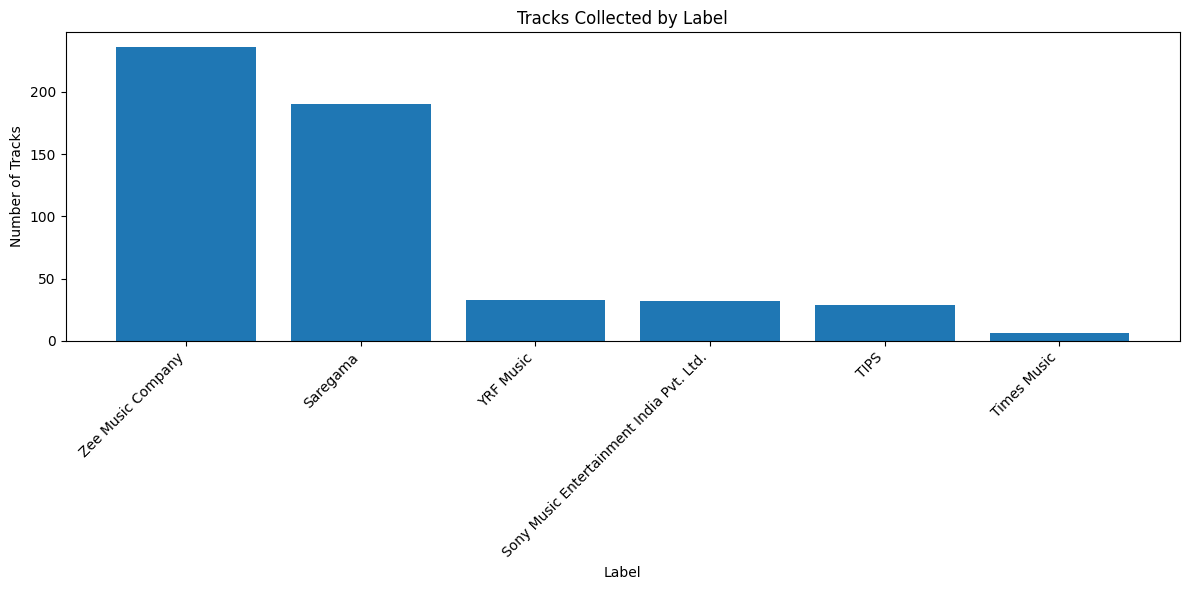

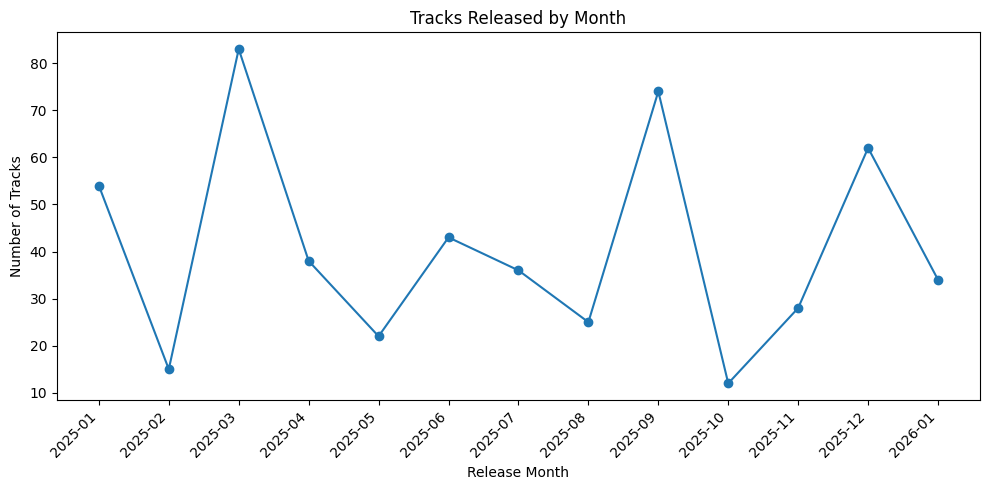

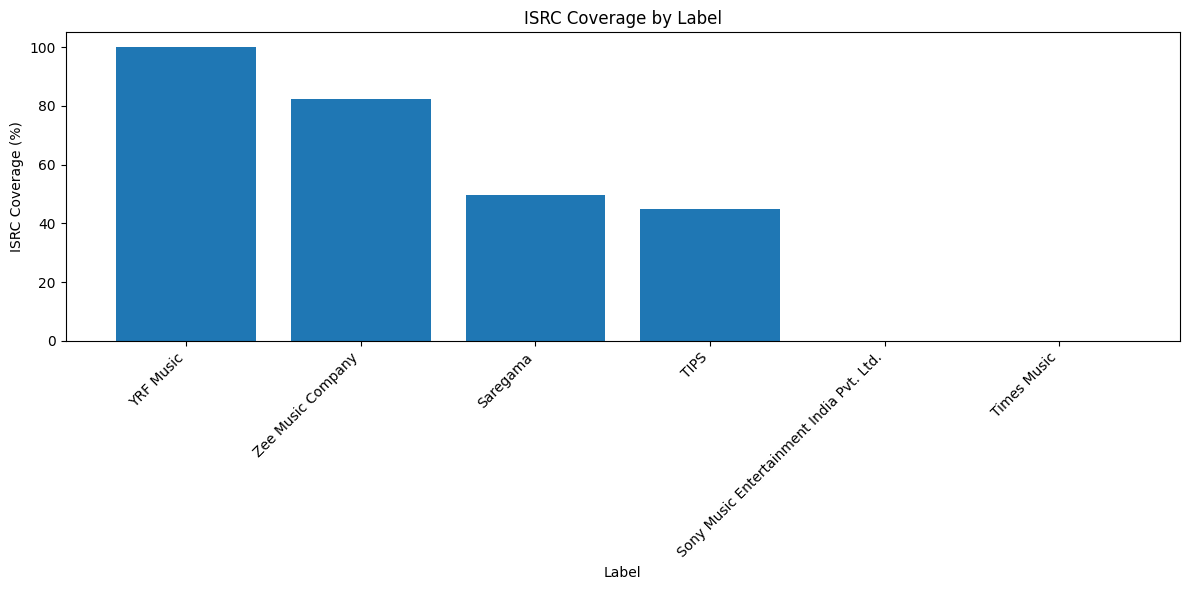

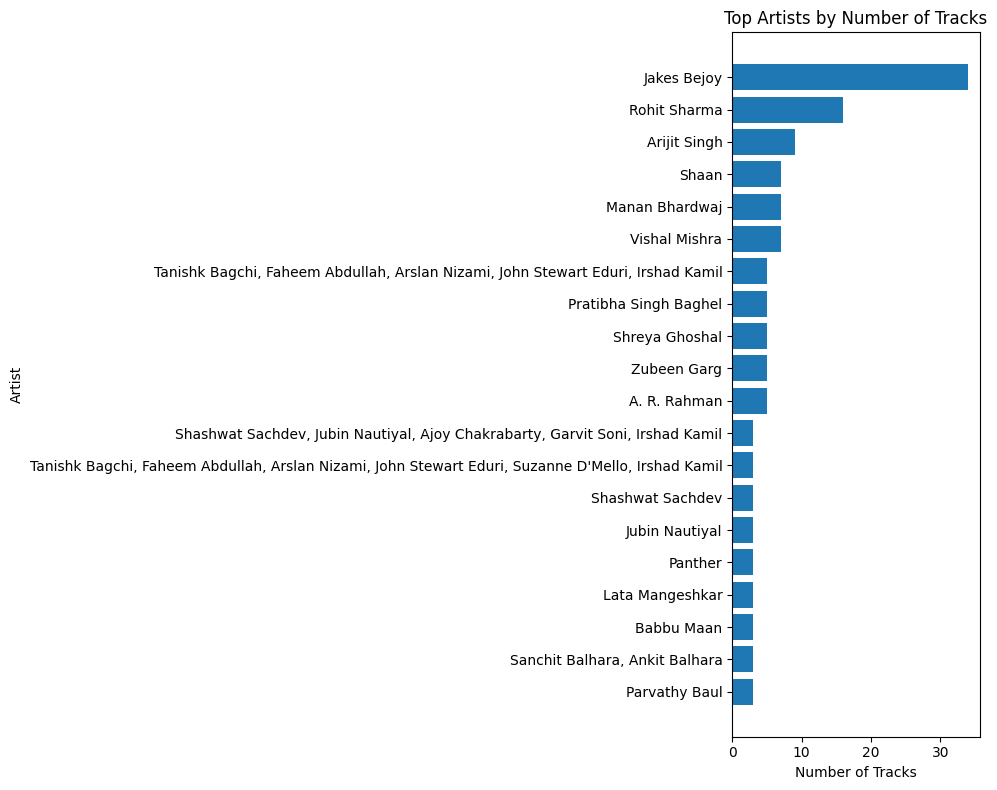

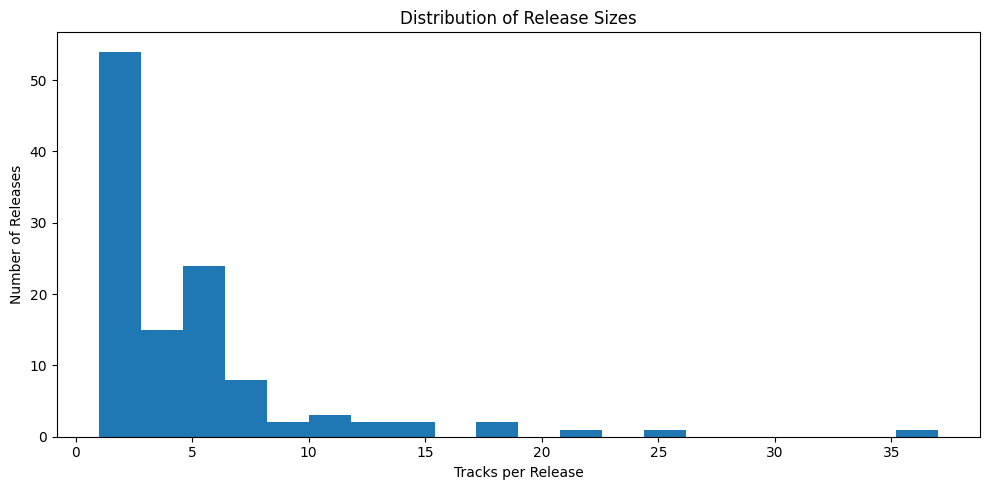


========== SUMMARY REPORT ==========


# MusicBrainz Indian Music Label ISRC Dataset

## Dataset Overview

This dataset contains track-level metadata and ISRC information collected from the MusicBrainz API.

**Collection period:** 2025-01-01 to 2026-01-31

| Metric | Value |
|---|---:|
| Total tracks | 526 |
| Total labels | 6 |
| Total releases | 115 |
| Total artists | 384 |
| Overall ISRC coverage | 63.50% |

---

## Labels Included

Zee Music Company, Sony Music India, Saregama, Tips Music, Times Music, Junglee Music, YRF Music, Ishtar Music, Eros Now Music

---

## Tracks by Label

| label                                    |   track_count |
|:-----------------------------------------|--------------:|
| Zee Music Company                        |           236 |
| Saregama                                 |           190 |
| YRF Music                                |            33 |
| Sony Music Entertainment India Pvt. Ltd. |            32 |
| TIPS                                     |            29 |
| Times Music                              |             6 |

---

## ISRC Coverage by Label

| label                                    |   isrc_coverage_percent |
|:-----------------------------------------|------------------------:|
| YRF Music                                |                100      |
| Zee Music Company                        |                 82.2034 |
| Saregama                                 |                 49.4737 |
| TIPS                                     |                 44.8276 |
| Sony Music Entertainment India Pvt. Ltd. |                  0      |
| Times Music                              |                  0      |

---

## Top Artists

| artist                                                                                            |   track_count |
|:--------------------------------------------------------------------------------------------------|--------------:|
| Jakes Bejoy                                                                                       |            34 |
| Rohit Sharma                                                                                      |            16 |
| Arijit Singh                                                                                      |             9 |
| Shaan                                                                                             |             7 |
| Manan Bhardwaj                                                                                    |             7 |
| Vishal Mishra                                                                                     |             7 |
| Tanishk Bagchi, Faheem Abdullah, Arslan Nizami, John Stewart Eduri, Irshad Kamil                  |             5 |
| Pratibha Singh Baghel                                                                             |             5 |
| Shreya Ghoshal                                                                                    |             5 |
| Zubeen Garg                                                                                       |             5 |
| A. R. Rahman                                                                                      |             5 |
| Shashwat Sachdev, Jubin Nautiyal, Ajoy Chakrabarty, Garvit Soni, Irshad Kamil                     |             3 |
| Tanishk Bagchi, Faheem Abdullah, Arslan Nizami, John Stewart Eduri, Suzanne D'Mello, Irshad Kamil |             3 |
| Shashwat Sachdev                                                                                  |             3 |
| Jubin Nautiyal                                                                                    |             3 |
| Panther                                                                                           |             3 |
| Lata Mangeshkar                                                                                   |             3 |
| Babbu Maan                                                                                        |             3 |
| Sanchit Balhara, Ankit Balhara                                                                    |             3 |
| Parvathy Baul                                                                                     |             3 |

---

## Dataset Files

The notebook creates the following Kaggle output files:

- `musicbrainz_isrc_2025-01-01_to_2026-01-31.csv`
- `musicbrainz_isrc_2025-01-01_to_2026-01-31.parquet`
- `musicbrainz_isrc_2025-01-01_to_2026-01-31_summary_report.md`
- `tracks_by_label.png`
- `tracks_by_month.png`
- `isrc_coverage_by_label.png`
- `top_artists.png`
- `release_size_distribution.png`

---

## Notes and Limitations

- The dataset depends on the completeness of MusicBrainz metadata.
- Some labels may have fewer records because MusicBrainz may not contain all releases.
- Some releases may not include ISRCs.
- Label matching depends on MusicBrainz naming conventions.
- CSV is suitable for general reuse.
- Parquet is suitable for larger analytical workflows.

---

Generated on: 2026-06-17 16:55:30



========== FINAL KAGGLE OUTPUT FILES ==========
/kaggle/working/musicbrainz_isrc_2025-01-01_to_2026-01-31.csv
/kaggle/working/musicbrainz_isrc_2025-01-01_to_2026-01-31.parquet
/kaggle/working/musicbrainz_isrc_2025-01-01_to_2026-01-31_summary_report.md
/kaggle/working/tracks_by_label.png
/kaggle/working/tracks_by_month.png
/kaggle/working/isrc_coverage_by_label.png
/kaggle/working/top_artists.png
/kaggle/working/release_size_distribution.png


In [20]:
# -----------------------------
# 11. Run full workflow
# -----------------------------

print("Starting MusicBrainz ISRC data collection")
print("Labels:", LABELS)
print("Date range:", START_DATE, "to", END_DATE)

df = collect_musicbrainz_dataset()

if df.empty:
    print("No records were collected.")
    print("Try increasing the date range or changing the labels.")

else:
    print("\nData collection completed successfully.")

    # Save main Kaggle dataset files
    df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    df.to_parquet(OUTPUT_PARQUET, index=False)

    print("\nMain files saved:")
    print("CSV:", OUTPUT_CSV)
    print("Parquet:", OUTPUT_PARQUET)

    # EDA
    eda_tables = create_eda_tables(df)

    # Display dataset preview
    print("\n========== DATASET PREVIEW ==========")
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", None)

    display(df)

    print("\n========== DATASET SHAPE ==========")
    print(df.shape)

    print("\n========== TRACKS BY LABEL ==========")
    display(eda_tables["tracks_by_label"])

    print("\n========== TRACKS BY MONTH ==========")
    display(eda_tables["tracks_by_month"])

    print("\n========== ISRC COVERAGE BY LABEL ==========")
    display(eda_tables["isrc_coverage_by_label"])

    print("\n========== TOP ARTISTS ==========")
    display(eda_tables["top_artists"])

    print("\n========== SELECTED DATASET COLUMNS ==========")
    useful_columns = [
        "label",
        "release_date",
        "release_title",
        "track_number",
        "track_title",
        "artist",
        "isrc",
        "musicbrainz_release_url",
    ]

    display(df[useful_columns].head(30))

    # Visualizations
    print("\n========== VISUALIZATIONS ==========")
    save_and_show_plots(df, eda_tables)

    # Summary report
    report_text = create_summary_report(df, eda_tables)

    print("\n========== SUMMARY REPORT ==========")
    display(Markdown(report_text))

    print("\n========== FINAL KAGGLE OUTPUT FILES ==========")
    output_files = [
        OUTPUT_CSV,
        OUTPUT_PARQUET,
        SUMMARY_REPORT,
        TRACKS_BY_LABEL_PLOT,
        TRACKS_BY_MONTH_PLOT,
        ISRC_COVERAGE_PLOT,
        TOP_ARTISTS_PLOT,
        RELEASE_SIZE_PLOT,
    ]

    for file in output_files:
        print(file)

## Output Files

The notebook generates the following files:

- CSV dataset
- Parquet dataset
- Markdown summary report
- Tracks by label plot
- Tracks by month plot
- ISRC coverage plot
- Top artists plot
- Release size distribution plot

These files are saved in:

`/kaggle/working/`

They can be downloaded from the notebook output section after running the notebook.

## Notes and Limitations

This dataset depends on the completeness and accuracy of MusicBrainz metadata.

Some limitations should be considered:

- Some labels may not have complete release records in MusicBrainz.
- Some releases may not contain ISRC codes.
- Label names may resolve to official MusicBrainz names that differ from the input names.
- Artist credits may vary depending on how the release was entered in MusicBrainz.
- The dataset reflects MusicBrainz metadata availability, not the full commercial catalogue of every label.

To modify the notebook, edit the configuration section. Add or remove labels in the `LABELS` list, change `START_DATE` and `END_DATE`, or set `MAX_RELEASES_PER_LABEL` to control dataset size.